In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv("Creditcard_data.csv")

fraud = data[data["Class"] == 1]
non_fraud = data[data["Class"] == 0]

# Random Undersampling to balance
non_fraud_sample = non_fraud.sample(len(fraud), random_state=42)
balanced_data = pd.concat([fraud, non_fraud_sample]).sample(frac=1, random_state=42)

balanced_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
182,118,1.254914,0.350287,0.302488,0.693114,-0.371470,-1.070256,0.086781,-0.202836,0.035154,...,-0.287592,-0.832682,0.128083,0.339427,0.215944,0.094704,-0.023354,0.030892,2.69,1
766,574,1.257719,0.364739,0.306923,0.690638,-0.357792,-1.067481,0.094272,-0.210300,0.014455,...,-0.286856,-0.820658,0.127663,0.343128,0.221120,0.094391,-0.022189,0.030944,1.29,1
639,484,-0.928088,0.398194,1.741131,0.182673,0.966387,-0.901004,0.879016,-0.156590,-0.142117,...,0.066353,0.281378,-0.257966,0.385384,0.391117,-0.453853,-0.104448,-0.125765,1.00,1
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1


In [3]:
# 1. Simple Random Sampling
simple_random = balanced_data.sample(frac=0.8, random_state=1)

# 2. Systematic Sampling
k = 2
systematic = balanced_data.iloc[::k]

# 3. Stratified Sampling (keeping class ratio)
X_temp = balanced_data.drop("Class", axis=1)
y_temp = balanced_data["Class"]
X_strat, _, y_strat, _ = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)
stratified = pd.concat([X_strat, y_strat], axis=1)

# 4. Cluster Sampling (index based clusters)
cluster = balanced_data[balanced_data.index % 3 == 0]

# 5. Bootstrap Sampling
bootstrap = balanced_data.sample(frac=1, replace=True, random_state=42)

samples = [simple_random, systematic, stratified, cluster, bootstrap]

In [4]:
models = [
    LogisticRegression(max_iter=1000),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier(n_neighbors=3),
    SVC()
]

In [5]:
results = pd.DataFrame(
    index=["LogReg", "DecisionTree", "RandomForest", "KNN", "SVM"],
    columns=["Simple_Random", "Systematic", "Stratified", "Cluster", "Bootstrap"]
)

for i in range(len(models)):
    for j in range(len(samples)):
        X = samples[j].drop("Class", axis=1)
        y = samples[j]["Class"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )

        model = models[i]
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        results.iloc[i, j] = round(accuracy_score(y_test, preds) * 100, 2)

results

,Simple_Random,Systematic,Stratified,Cluster,Bootstrap
LogReg,80.0,66.67,60.0,100.0,100.0
DecisionTree,80.0,33.33,60.0,100.0,100.0
RandomForest,60.0,33.33,20.0,66.67,100.0
KNN,60.0,33.33,20.0,100.0,66.67
SVM,60.0,33.33,60.0,100.0,66.67


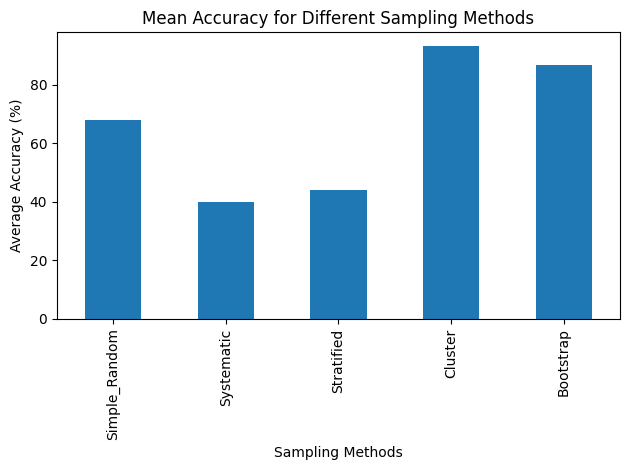

In [6]:
avg_accuracy = results.astype(float).mean()

plt.figure()
avg_accuracy.plot(kind="bar")
plt.xlabel("Sampling Methods")
plt.ylabel("Average Accuracy (%)")
plt.title("Mean Accuracy for Different Sampling Methods")
plt.tight_layout()
plt.savefig("results.png")
plt.show()